# CosmoSim Demo Part I

## Preparation

We will use pandas to handle sets of lensing systems with
different parameters, pyplot for plotting, PIL for images,
as well as config files in TOML.  Hence we import the following
modules.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import toml

From CosmoSim, we will use the main simulator `CosmoSim` and
the data generator `datagen`.

In [2]:
from CosmoSim import CosmoSim
from CosmoSim.datagen import SimImage
import CosmoSim.Image as csimg
from CosmoSim import Parameters

## Simulating an image

In this demo, we will use the following sample parameters, taken from a test by Ben David 6 May 2026.
CosmoSim can take parameters in many different formats.  CSV files are generally used for bulk processing,
while TOML is more convenient for individual samples. The notation is not always harmonised, and is shown here for reference.

| GUI Name |         Parameter | CSV name | TOML Name                 |
| :-       |         :-        | :-       | :-                        |
| Einstein Radius |  $R_E= 46$ | `einsteinR` | `lens.einsteinR`       |
| Ellipticity |      $0.34$    | `ellipseratio` | `lens.ellipseratio` |
| Lens Orientation | 107       | `orientation` | `lens.orientation`   |
| Distance Ratio (chi) | $\chi=50\%$ | `chi` | `lens.chi` |
| x |                    $x= 11.01$ | `x` | `position.x`  |
| y |                    $y= 0.31$  | `x` |  `position.y` |
| Source Size |     $\sigma=20$ | `sigma` | `source.sigma`|
| Source Rotation | 45° | `theta` | `source.theta`        |

::: {admonition} Warning
The terms used in the code and config files do not always reflect standard mathematical notation.
In particular, `theta` is not $\theta$ in current notation.

Typically, the CSV names reflect the identifiers used in the code, which make them tricky to change.
For the time being, we have to live with the ambiguity.
:::

## First test of the API

We can define the configuration as a dict using the nested (TOML) structure.

In [3]:
cfg = { 'lens': { 
            'einsteinR': 46,
            'ellipseratio': 0.34,
            'orientation': 107,
            'chi': 50}
      , 'source': {
            'mode': 'Spherical',
            'sigma': 20,
            'theta': 45,
            'position': 'cartesian'}
      , 'position': {'x': 11.01, 'y': 0.31}
      }

CosmoSim uses `Parameters` objects which store the parameters as a cascaded dictionary,
incorporating defaults.   This is instantiated using the `dict` that we just made.

In [4]:
param = Parameters( cfg )
print( param )

<{'lens': <{}, Ancestor: <{'einsteinR': 46, 'ellipseratio': 0.34, 'orientation': 107, 'chi': 50}, Ancestor: None>>, 'source': <{}, Ancestor: <{'mode': 'Spherical', 'sigma': 20, 'theta': 45, 'position': 'cartesian'}, Ancestor: None>>, 'position': <{}, Ancestor: <{}, Ancestor: <{'x': 11.01, 'y': 0.31}, Ancestor: None>>>, 'simulator': <{'configs': <{}, Ancestor: None>}, Ancestor: <{'configs': <{}, Ancestor: None>}, Ancestor: <{'configs': <{}, Ancestor: None>}, Ancestor: <{'configs': <{}, Ancestor: None>, 'imagesize': 512}, Ancestor: None>>>>, 'dataset': <{}, Ancestor: None>, 'annotation': <{}, Ancestor: None>, 'management': <{}, Ancestor: <{}, Ancestor: <{}, Ancestor: <{'maxcount': None, 'filename': 'test.png'}, Ancestor: None>>>>}, Ancestor: <{'lens': <{'einsteinR': 46, 'ellipseratio': 0.34, 'orientation': 107, 'chi': 50}, Ancestor: None>, 'source': <{'mode': 'Spherical', 'sigma': 20, 'theta': 45, 'position': 'cartesian'}, Ancestor: None>, 'position': <{}, Ancestor: <{'x': 11.01, 'y': 0.

::: {admonition} Remark
It is possible to define the config as a flat `dict` using the CSV labels, and
the convert it to the nested structure with the `getConfig()` function.
:::

We can simulate the configuration by merely instantiating a `SimImage` object, as follows.
The simulator runs as part of the instantiation.  
It is rather verbose, with debug messages still left in.

In [5]:
imsim = SimImage( param )

[SimImage] init (verbose=1) ...
[SimImage] setParameters()
[initSim] type(row)=<class 'CosmoSim.CLI.Arguments.Parameters'>
[makeSource] src=Spherical, ltprf0=None, verbose=1
[makeSource] mode=SourceSpec.Sphere, ltprf=LightProfileSpec.Gaussian
[SphericalSource] constructor done
CosmoSim.makeSource() returns (verbose=1
[SphericalSource] GAUSS
CSIM_NOPSI_PM
CSIM_MODEL_POINTMASS_EXACT
[initLens] returning 
[PsiFunctionLens.initAlphasBetas] Amplitudes file nosuchfile
[CosmoSim.initLens] no sampling
[SimulatorModel::setMaskMode] 0
[SimulatorModel::setSource] setting source
[SimulatorModel::update] Lens: Lens (Superclass)
[SimulatorModel::update] CHI=0.5
[SimulatorModel::getSource()]
[setNu] etaOffset set to zero.
[SimulatorModel::update] Done updateApparentAbs()
[SimulatorModel::update] thread section
[SimulatorModel::parallelDistort] 6 threads (maskMode=0)
[SimulatorModel] No mask 
[SimulatorModel::parallelDistort] lower=0; rng=1024; rng1=171
[SimulatorModel::distort] begin=171; end=342
[Si

Usually, this output is not interesting, but if we have relied heavily on defaults, we can read some of the values actually used from this output.
We see `GAUSS` indicating that a Gaussian light profile has been used for the source. We also see `POINTMASS_EXACT` which refers to the point mass lens, which is simulated with an exact formula equivalent to raytracing. We will get back to this later.

The interesting part is the image, which we can retrieve with a 
second line.

In [6]:
im = imsim.getImage()
print( im )
print( type( im ) )

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
<class 'numpy.ndarray'>


The image is a numpy *array*, but we can view it as a proper image using
`matplotlib`.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

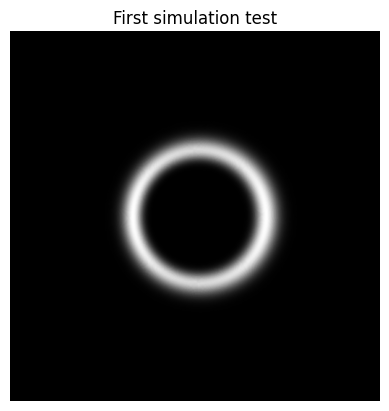

In [7]:
plt.imshow( im, cmap='gray')
plt.title( "First simulation test" )
plt.axis("off")

## More Complete configuration

For the second test, we will keep the configuration in a TOML file.
This tends to be easier to read than the `dict` in python code.
The file is [Demo01.toml](./Demo01.toml), and we read it thus:

In [8]:
import tomllib as tl
with open( "Demo01.toml", 'rb') as f:
            toml = tl.load(f)
print( toml )

{'simulator': {'config': 'raysie'}, 'lens': {'einsteinR': 46, 'ellipseratio': 0.34, 'orientation': 107, 'chi': 50}, 'source': {'mode': 'SersicSphere', 'sigma': 20, 'theta': 45, 'position': 'cartesian', 'n_sersic': 4, 'luminosity': 10}, 'position': {'x': 11.01, 'y': 0.31}}


The result is a nested python `dict` which we can import as we did before.

Most importantly, we are now defining `simulator.config=raysie`, which
says raytrace simulation with a SIE lens, and `source.mode=SersicSphere`
which says a spherical source with Sersic light profile.
The sersic parameters (`n_sersic` and `luminosity`) match the current
defaults in the GUI.

In the run below, we set `verbose=2` which gives extra diagnostic output.
This is just to demonstrate the feature.  It is only needed for debugging.

[GenericSim] init (verbose=2) ...
[SimImage] init (verbose=2) ...
[CosmoSim] init (verbose=2) ...
[initSim] using row
[SimImage] setParameters()
[setParameters] XY 11.01 0.31
setConfigMode(raysie)
[setConfigMode] (<ModelSpec.Raytrace: 0>, <PsiSpec.SIE: 1>, False)
index None
[initSim] type(row)=<class 'CosmoSim.CLI.Arguments.Parameters'>
[initSim] item name: test
[makeSource] src=SersicSphere, ltprf0=None, verbose=2
[makeSource] Lightprofile: SersicSphere LightProfileSpec.Sersic
[makeSource] mode=SourceSpec.Sphere, ltprf=LightProfileSpec.Sersic
[makeSource] Spherical Source - n_sersic=4.0, luminosity=10.0
[SphericalSource] constructor done
makeSource() returns
CosmoSim.makeSource() returns (verbose=2
[GenericSim] ready for runSim()

[SphericalSource] SERSIC
setFile /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[initLens] returning 
[PsiFunctionLens.initAlphasBetas] Amplitudes file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[initAlphasBetas] opened file /home/georg

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

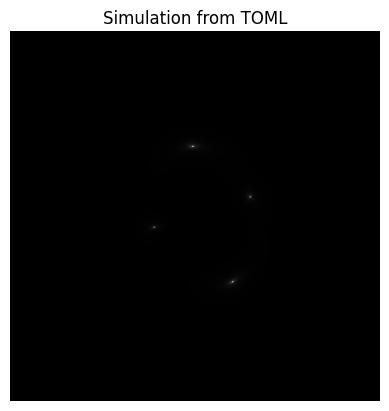

In [9]:
param = Parameters( toml )
imsim = SimImage( param, verbose=2 )
im = imsim.getImage()
plt.imshow( im, cmap='gray')
plt.title( "Simulation from TOML" )
plt.axis("off")

## Comparing simulation models

For the simulation of SIE lenses, `CosmoSim` provides a total of four
different simulation models
+ Raytrace is the exact simulation, as used above.
+ Roulette uses the Roulette formalism, which approximates using a
  local description of the lens potential

Each of these can also be run in a sampled version, where the lens potential
is sampled and differentiated numerically, instead of using algebraic functions
derived analytically.

To test different models, we can set `simulator.model`, which will override
`simulator.config`, while keeping the SIE lens.

[SimImage] setParameters()
setModelMode(Roulette)
[initSim] type(row)=<class 'CosmoSim.CLI.Arguments.Parameters'>
CosmoSim.makeSource() returns (verbose=0
[SphericalSource] SERSIC
setFile /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
Instantiating RouletteModel ... 
[initLens] returning 
[PsiFunctionLens.initAlphasBetas] Amplitudes file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[initAlphasBetas] opened file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[CosmoSim.initLens] no sampling
[SimulatorModel::setMaskMode] 0
[SimulatorModel::setSource] setting source
[SimulatorModel::update] Lens: Lens (Superclass)
[SimulatorModel::update] CHI=0.5
[SimulatorModel::getSource()]
[Lens::getXi] [5.505, 0.155]
[Lens] Fix pt it'n 0; xi0=[5.505, 0.155]; Delta eta = 36.6416, -9.08535
[Lens] Fix pt it'n 1; xi0=[42.1466, -8.93035]; Delta eta = 35.5485, -22.0062
[Lens] Fix pt it'n 2; xi0=[41.0535, -21.8512]; Delta eta = 31.7068, -32.7793
[Lens] Fix pt it'n 3; xi0=[37.2118,

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

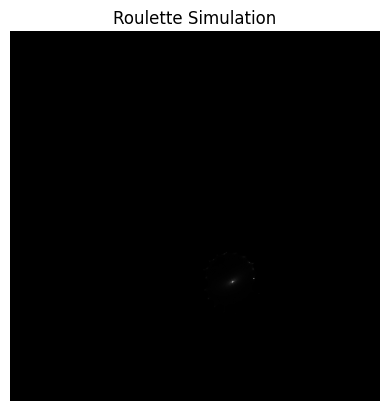

In [10]:
param["simulator"]["model"] = "Roulette"
imsimRoulette = SimImage( param, verbose=0 )
imRoulette = imsimRoulette.getImage()
plt.imshow( imRoulette, cmap='gray')
plt.title( "Roulette Simulation" )
plt.axis("off")

Because the source is small and provides little light, it is hard
to distinguish the simulation models, but the critical point with Roulette
is that it only provides a local description of the primary image.  The
secondary image on the far side of the lens will never appear in a roulette
simulation.

Before we tamper with the source description, we will run sampled simulations 
as follows.

In [11]:
param["simulator"]["model"] = "Roulette"
param["simulator"]["sampled"] = True
imsimRouletteSampled = SimImage( param, verbose=0 )
imRouletteSampled = imsimRouletteSampled.getImage()

param["simulator"]["model"] = "Raytrace"
param["simulator"]["sampled"] = True
imsimRaytraceSampled = SimImage( param, verbose=0 )
imRaytraceSampled = imsimRaytraceSampled.getImage()

[SimImage] setParameters()
setModelMode(Roulette)
[initSim] type(row)=<class 'CosmoSim.CLI.Arguments.Parameters'>
CosmoSim.makeSource() returns (verbose=0
[SphericalSource] SERSIC
setFile /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
Instantiating RouletteModel ... 
[initLens] returning 
[PsiFunctionLens.initAlphasBetas] Amplitudes file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[initAlphasBetas] opened file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[CosmoSim.initLens] ready to sample lens
[SampledPsiFunctionLens] updatePsi() returns
[CosmoSim.initLens] lens sampled
[SimulatorModel::setMaskMode] 0
[SimulatorModel::setSource] setting source
[SimulatorModel::update] Lens: Lens (Superclass)
[SimulatorModel::update] CHI=0.5
[SimulatorModel::getSource()]
[Lens::getXi] [5.505, 0.155]
[Lens] Fix pt it'n 0; xi0=[5.505, 0.155]; Delta eta = 36.2352, -10.4745
[Lens] Fix pt it'n 1; xi0=[41.7402, -10.3195]; Delta eta = 35.2898, -23.1337
[Lens] Fix pt it'n 2; xi0

::: {admonition} Remark
It is unfortunate that we cannot suppress diagnostic output from the C++
modules at the moment.  This is on the bucket list.
:::

To better compare, we will show the four images side by side.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

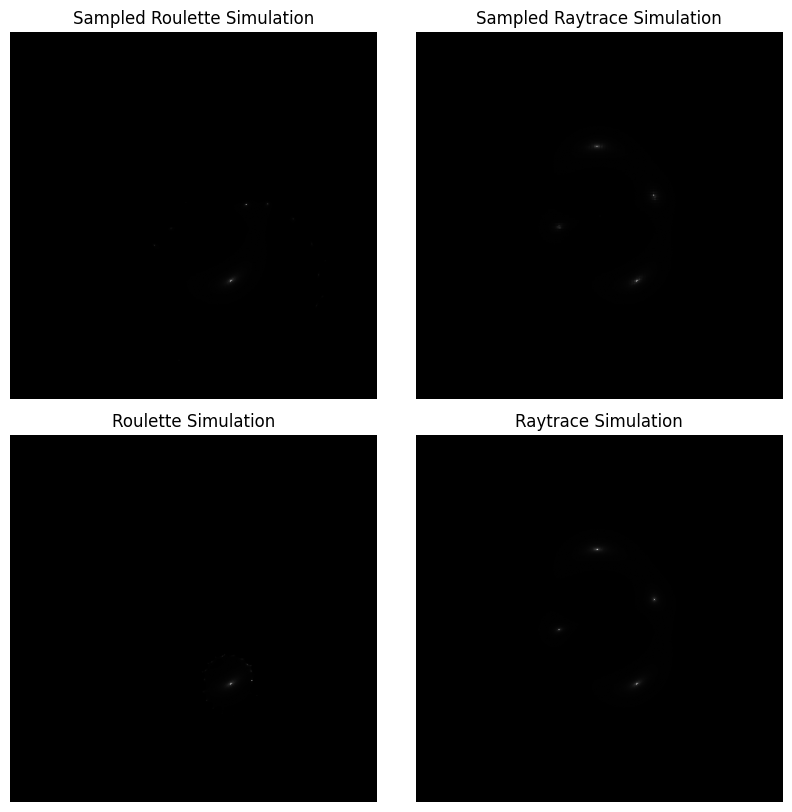

In [12]:
fig = plt.figure(figsize=(10, 10))
fig.tight_layout(pad=0.0)
plt.subplots_adjust(hspace=0.1, wspace=0.1) 

fig.add_subplot(2, 2, 1)
plt.imshow( imRouletteSampled, cmap='gray')
plt.title( "Sampled Roulette Simulation" )
plt.axis("off")

fig.add_subplot(2, 2, 2)
plt.imshow( imRaytraceSampled, cmap='gray')
plt.title( "Sampled Raytrace Simulation" )
plt.axis("off")

fig.add_subplot(2, 2, 3)
plt.imshow( imRoulette, cmap='gray')
plt.title( "Roulette Simulation" )
plt.axis("off")

fig.add_subplot(2, 2, 4)
plt.imshow( im, cmap='gray')
plt.title( "Raytrace Simulation" )
plt.axis("off")

## A convenience function

The following function does the four simulations and plots above,
for any given set of parameters `param`.
When we fiddle with the source (or lens) description, we will use
this to run all tests at once.

In [13]:
def quadSim( param ):
    param["simulator"]["model"] = "Roulette"
    param["simulator"]["sampled"] = True
    imsimRouletteSampled = SimImage( param, verbose=0 )
    imRouletteSampled = imsimRouletteSampled.getImage()

    param["simulator"]["sampled"] = False
    imsimRoulette = SimImage( param, verbose=0 )
    imRoulette = imsimRoulette.getImage()

    param["simulator"]["model"] = "Raytrace"
    param["simulator"]["sampled"] = True
    imsimRaytrace = SimImage( param, verbose=0 )
    imRaytrace = imsimRaytrace.getImage()

    param["simulator"]["sampled"] = False
    imsimRaytraceSampled = SimImage( param, verbose=0 )
    imRaytraceSampled = imsimRaytraceSampled.getImage()

    fig = plt.figure(figsize=(10, 10))
    fig.tight_layout(pad=0.0)
    plt.subplots_adjust(hspace=0.1, wspace=0.1) 

    fig.add_subplot(2, 2, 1)
    plt.imshow( imRouletteSampled, cmap='gray')
    plt.title( "Sampled Roulette Simulation" )
    plt.axis("off")

    fig.add_subplot(2, 2, 2)
    plt.imshow( imRaytraceSampled, cmap='gray')
    plt.title( "Sampled Raytrace Simulation" )

    plt.axis("off")

    fig.add_subplot(2, 2, 3)
    plt.imshow( imRoulette, cmap='gray')
    plt.title( "Roulette Simulation" )
    plt.axis("off")
    
    fig.add_subplot(2, 2, 4)
    plt.imshow( imRaytrace, cmap='gray')
    plt.title( "Raytrace Simulation" )
    plt.axis("off")

    return( imRaytrace, imRoulette, imRaytraceSampled, imRouletteSampled )

## The triangle source

The triangle source is specially designed for visual comparison of lensing
configurations.  This is what we get.

[SimImage] setParameters()
setModelMode(Roulette)
[initSim] type(row)=<class 'CosmoSim.CLI.Arguments.Parameters'>
CosmoSim.makeSource() returns (verbose=0
setFile /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
Instantiating RouletteModel ... 
[initLens] returning 
[PsiFunctionLens.initAlphasBetas] Amplitudes file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[initAlphasBetas] opened file /home/georg/git/cosmoai/CosmoSim/src/CosmoSim/sie05.txt
[CosmoSim.initLens] ready to sample lens
[SampledPsiFunctionLens] updatePsi() returns
[CosmoSim.initLens] lens sampled
[SimulatorModel::setMaskMode] 0
[SimulatorModel::setSource] setting source
[SimulatorModel::update] Lens: Lens (Superclass)
[SimulatorModel::update] CHI=0.5
[SimulatorModel::getSource()]
[Lens::getXi] [5.505, 0.155]
[Lens] Fix pt it'n 0; xi0=[5.505, 0.155]; Delta eta = 36.2352, -10.4745
[Lens] Fix pt it'n 1; xi0=[41.7402, -10.3195]; Delta eta = 35.2898, -23.1337
[Lens] Fix pt it'n 2; xi0=[40.7948, -22.9787]; Del

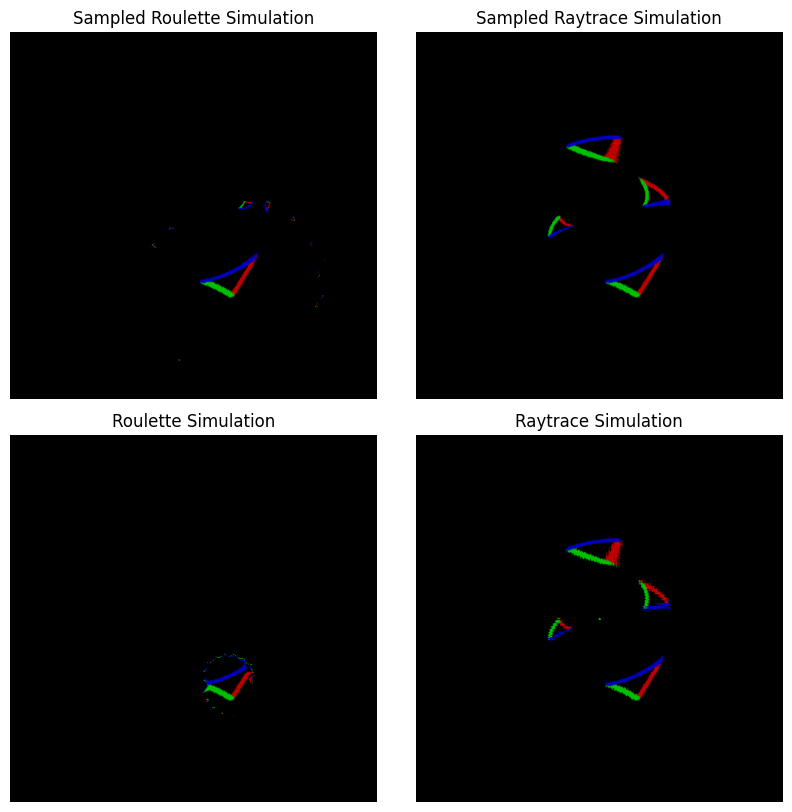

In [14]:
param["source"]["mode"] = "Triangle"
(im1,im2,im3,im4) = quadSim( param )

Since we stored the four images in variables (`im1` through `im4`), we can
also compare them using difference images.  However, we have to take the range
($0\ldots255$) into account when we calculate the difference.  The following
function does this

In [15]:
def imageDiff(im1,im2):
    return ( (im1.astype(float) - im2.astype(float) + 256)/2 ).astype(np.uint8)

Armed with the function, we can plot diff images.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

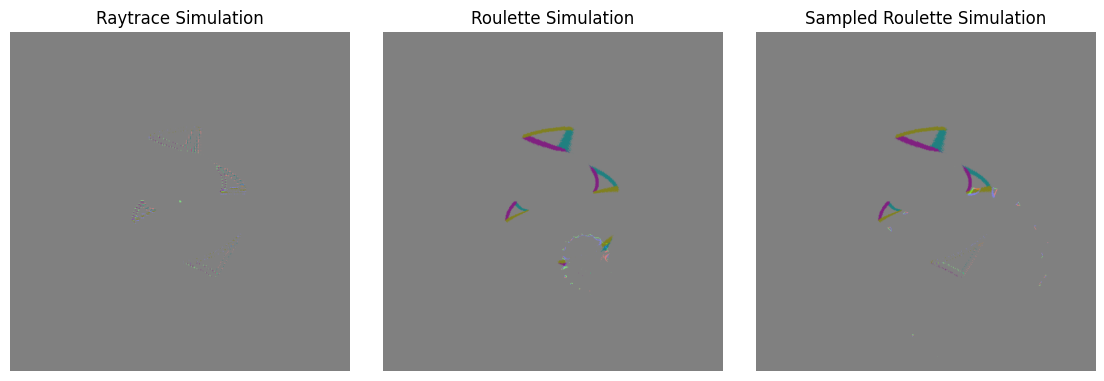

In [17]:
fig = plt.figure(figsize=(14,7))
fig.tight_layout(pad=0.0)
plt.subplots_adjust(hspace=0.1, wspace=0.1) 

fig.add_subplot(1, 3, 1)
plt.imshow( imageDiff( im1, im3 ), cmap='gray')
plt.title( "Raytrace Simulation" )
plt.axis("off")

fig.add_subplot(1, 3, 2)
plt.imshow( imageDiff( im2, im3 ), cmap='gray')
plt.title( "Roulette Simulation" )
plt.axis("off")
    
fig.add_subplot(1, 3, 3)
plt.imshow( imageDiff( im4, im3 ), cmap='gray')
plt.title( "Sampled Roulette Simulation" )
plt.axis("off")

We see that the two raytrace simulations perfectly match, except for the
tiny anomilty in the centre, which is probably due to the singularity of
the lens potential at the origin.

The roulette simulations match well within the convergence ring.

What should concern us at the minute is the very small convergence ring 
for the unsampled roulette simulation.  This does look wrong.

# Annotation

It is possible to annotate images, something we have not shown above.
The following example was used in a different demo and could be adapted.

```
def annotatedSim(imsim):
    im = imsim.getAnnotated()
    print( "Centre point", imsim.centrepoint )
    print( "Prior shape", im.shape )
    csimg.drawAxes( im )
    im = csimg.crop( im )
    print( "Posterior shape", im.shape )
    return im
im = annotatedSim(imsim)
plt.axis("off")
plt.title( fn )
plt.imshow(im)
```